In [1]:
# ============================================================
# H3 - CTAS URGENCY SCORE AS A PREDICTOR OF REPORTED MEDIAN ED LOS
# ============================================================
# Research question : Does CTAS urgency score significantly predict reported median ED LOS?
# Null hypothesis   : The slope of LOS on CTAS urgency score is zero.
# Alternative       : The slope of LOS on CTAS urgency score is non-zero.
# Method            : Weighted Least Squares (WLS) linear regression
#
# Visits weight each observation; the exact Student-t tail supplies the p-value.
#
# The test itself is NOT reimplemented here. It is imported from
# backend.analytics.statistics.weighted, the same engine the API serves, so this
# notebook and the production endpoint cannot report different numbers.

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 150)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Resolve the project root so the notebook runs from any working directory.
PROJECT_ROOT = Path.cwd().resolve()

while not (PROJECT_ROOT / "backend").is_dir() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

RAW_DIR = PROJECT_ROOT / "data" / "Explorer Dataset"
CLEAN_DIR = RAW_DIR / "cleaned"
WORKBOOK = PROJECT_ROOT / "data" / "cleaned dataset" / "Explanatory_and_Predictive_ED_Analytics_Dataset.xlsx"

ALPHA = 0.05

print("Project root :", PROJECT_ROOT)
print("Alpha        :", ALPHA)

Project root : C:\Users\amitd\Downloads\Desktoppp\UNF\UNF Assignment _ Notes_Class Practise\Term 5\Capstone\Github\Capstone_Project-DAMO-6994-
Alpha        : 0.05


In [3]:
# Prefer the cleaned copy written by data/Explorer Dataset/Explorer_Dataset_Cleaning.ipynb.
SOURCE = CLEAN_DIR / "CTAS_Triage.csv"

if not SOURCE.exists():
    SOURCE = RAW_DIR / "CTAS_Triage.csv"

df = pd.read_csv(SOURCE)

print("Source file :", SOURCE.relative_to(PROJECT_ROOT))
print("Shape       :", df.shape)
print("Cleaned copy:", SOURCE.parent == CLEAN_DIR)

Source file : data\Explorer Dataset\cleaned\CTAS_Triage.csv
Shape       : (912, 11)
Cleaned copy: True


In [4]:
print("FIRST 10 ROWS")
print("-" * 80)

display(df.head(10))

FIRST 10 ROWS
--------------------------------------------------------------------------------


,fiscal_year,fiscal_year_start,sex,triage_level,ctas_urgency_score,age_group,population_category,ed_visits,median_los_minutes,median_los_hours,is_suppressed
0,2021-2022,2021,Female,CTAS I - Resuscitation,1,0-19,Pediatric & Youth,10332,240.0,4.0,0
1,2021-2022,2021,Female,CTAS I - Resuscitation,1,20-44,Young Adult,11051,330.0,5.5,0
2,2021-2022,2021,Female,CTAS I - Resuscitation,1,45-64,Middle Adult,11653,324.0,5.4,0
3,2021-2022,2021,Female,CTAS I - Resuscitation,1,65+,Older Adult,25787,414.0,6.9,0
4,2021-2022,2021,Male,CTAS I - Resuscitation,1,0-19,Pediatric & Youth,12409,228.0,3.8,0
5,2021-2022,2021,Male,CTAS I - Resuscitation,1,20-44,Young Adult,18848,336.0,5.6,0
6,2021-2022,2021,Male,CTAS I - Resuscitation,1,45-64,Middle Adult,20762,300.0,5.0,0
7,2021-2022,2021,Male,CTAS I - Resuscitation,1,65+,Older Adult,30338,360.0,6.0,0
8,2021-2022,2021,Female,CTAS II - Emergent,2,0-19,Pediatric & Youth,208386,228.0,3.8,0
9,2021-2022,2021,Female,CTAS II - Emergent,2,20-44,Young Adult,416879,282.0,4.7,0


In [5]:
print("COLUMN NAMES AND TYPES")
print("-" * 80)

display(pd.DataFrame({
    "Column": df.columns,
    "Data_Type": df.dtypes.astype(str).values,
    "Missing": [int(df[c].isna().sum()) for c in df.columns],
}))

COLUMN NAMES AND TYPES
--------------------------------------------------------------------------------


,Column,Data_Type,Missing
0,fiscal_year,str,0
1,fiscal_year_start,int64,0
2,sex,str,0
3,triage_level,str,0
4,ctas_urgency_score,int64,0
5,age_group,str,0
6,population_category,str,0
7,ed_visits,int64,0
8,median_los_minutes,float64,0
9,median_los_hours,float64,0


In [6]:
print("DATA QUALITY CHECKS")
print("-" * 80)

print(f"Rows              : {len(df):,}")
print(f"Duplicate rows    : {df.duplicated().sum():,}")
print(f"Total missing     : {df.isna().sum().sum():,}")

if "ed_visits" in df.columns:
    print(f"ED visits <= 0    : {(df['ed_visits'] <= 0).sum():,}")
    print(f"Total ED visits   : {df['ed_visits'].sum():,.0f}")

if "median_los_minutes" in df.columns:
    print(f"LOS < 0           : {(df['median_los_minutes'] < 0).sum():,}")

DATA QUALITY CHECKS
--------------------------------------------------------------------------------
Rows              : 912
Duplicate rows    : 0
Total missing     : 0
ED visits <= 0    : 0
Total ED visits   : 175,762,944
LOS < 0           : 0


In [7]:
from backend.analytics.statistics.weighted import student_t_sf, weighted_mean

print("Weighted engine imported from backend.analytics.statistics.weighted")

Weighted engine imported from backend.analytics.statistics.weighted


In [8]:
# ------------------------------------------------------------
# PREDICTOR DIAGNOSTIC - READ THIS BEFORE INTERPRETING H3
# ------------------------------------------------------------
# ctas_urgency_score is the sole predictor. If distinct triage levels share a score,
# the regression is structurally unable to separate them.

score_map = (
    df.groupby("triage_level")["ctas_urgency_score"]
    .agg(["min", "max", "nunique"])
    .reset_index()
)

display(score_map)

collisions = (
    df.groupby("ctas_urgency_score")["triage_level"]
    .nunique()
    .reset_index(name="distinct_triage_levels")
)

display(collisions)

worst = int(collisions["distinct_triage_levels"].max())

print(f"Maximum triage levels sharing one score: {worst}")
print()

if worst > 1:
    print("WARNING: the predictor is degenerate. Triage levels that share a score are")
    print("indistinguishable to the model, so any slope or R^2 below is a LOWER BOUND")
    print("on the true acuity-LOS relationship. Treating triage_level as an ordered")
    print("factor would recover the collapsed contrast.")

,triage_level,min,max,nunique
0,CTAS I - Resuscitation,1,1,1
1,CTAS II - Emergent,2,2,1
2,CTAS III - Urgent,3,3,1
3,Less urgent,3,3,1
4,Non-urgent,3,3,1
5,Unknown,3,3,1


,ctas_urgency_score,distinct_triage_levels
0,1,1
1,2,1
2,3,4


Maximum triage levels sharing one score: 4

indistinguishable to the model, so any slope or R^2 below is a LOWER BOUND
on the true acuity-LOS relationship. Treating triage_level as an ordered
factor would recover the collapsed contrast.


In [9]:
h3_df = df.dropna(subset=["ctas_urgency_score", "median_los_minutes", "ed_visits"]).copy()
h3_df = h3_df[(h3_df["ed_visits"] > 0) & (h3_df["median_los_minutes"] >= 0)]

# Unknown has no defined acuity, so it must not contribute to an acuity slope.
h3_df = h3_df[h3_df["triage_level"].astype(str).str.strip() != "Unknown"]

print("H3 ANALYSIS DATASET")
print("=" * 80)
print(f"Original records        : {len(df):,}")
print(f"Records after filtering : {len(h3_df):,}")
print(f"Total frequency weight  : {h3_df['ed_visits'].sum():,.0f}")
print(f"Distinct urgency scores : {sorted(h3_df['ctas_urgency_score'].unique())}")

H3 ANALYSIS DATASET
Original records        : 912
Records after filtering : 760
Total frequency weight  : 174,207,395
Distinct urgency scores : [np.int64(1), np.int64(2), np.int64(3)]


In [10]:
x = h3_df["ctas_urgency_score"].to_numpy(dtype=float)
y = h3_df["median_los_minutes"].to_numpy(dtype=float)
w = h3_df["ed_visits"].to_numpy(dtype=float)

# Weighted least squares closed form for a simple linear model.
W = w.sum()
x_bar = (w * x).sum() / W
y_bar = (w * y).sum() / W

s_xx = (w * (x - x_bar) ** 2).sum()
s_xy = (w * (x - x_bar) * (y - y_bar)).sum()
s_yy = (w * (y - y_bar) ** 2).sum()

slope = s_xy / s_xx
intercept = y_bar - slope * x_bar

y_hat = intercept + slope * x
ss_res = (w * (y - y_hat) ** 2).sum()
r_squared = 1 - ss_res / s_yy
correlation = s_xy / np.sqrt(s_xx * s_yy)

# Standard WLS slope variance: sigma^2 / S_xx, with sigma^2 the weighted residual
# variance on n-2 df. This treats each AGGREGATE ROW as one observation (matching
# statsmodels.WLS) rather than each visit; weighting the visits themselves would
# claim n = weighted N degrees of freedom, which is not how many independent
# CTAS-level LOS medians were actually reported.
n_obs = len(x)
df_resid = n_obs - 2
residual_variance = ss_res / df_resid
se_slope = np.sqrt(residual_variance / s_xx)

t_stat = slope / se_slope
p_value = min(1.0, 2 * student_t_sf(abs(t_stat), df_resid))

print("H3 - WEIGHTED LEAST SQUARES REGRESSION")
print("-" * 80)
print(f"Slope (beta1)          : {slope:.6f} minutes per urgency point")
print(f"Intercept (beta0)      : {intercept:.6f}")
print(f"Standard error (slope) : {se_slope:.6f}")
print(f"t statistic            : {t_stat:.6f}")
print(f"Degrees of freedom     : {df_resid}")
print(f"P-value                : {p_value:.10f}")
print(f"R squared              : {r_squared:.6f}")
print(f"Pearson correlation    : {correlation:.6f}")
print(f"Aggregate observations : {n_obs:,}")
print(f"Total frequency weight : {W:,.0f}")

H3 - WEIGHTED LEAST SQUARES REGRESSION
--------------------------------------------------------------------------------
Slope (beta1)          : -115.717906 minutes per urgency point
Intercept (beta0)      : 511.465482
Standard error (slope) : 6.180375
t statistic            : -18.723444
Degrees of freedom     : 758
P-value                : 0.0000000000
R squared              : 0.316235
Pearson correlation    : -0.562347
Aggregate observations : 760
Total frequency weight : 174,207,395


In [11]:
print("=" * 80)
print("H3 HYPOTHESIS DECISION")
print("=" * 80)
print("Significance level (alpha):", ALPHA)
print(f"P-value: {p_value:.10f}")
print()

if p_value < ALPHA:
    print("Decision: REJECT H0")
    print()
    print("Conclusion:")
    print(f"CTAS urgency score is a statistically significant predictor of reported")
    print(f"median ED LOS. Each additional urgency point is associated with a change")
    print(f"of {slope:.2f} minutes, explaining {r_squared*100:.1f}% of weighted variance.")
else:
    print("Decision: FAIL TO REJECT H0")
    print()
    print("Conclusion:")
    print("CTAS urgency score does not significantly predict reported median ED LOS.")

print()
print("Caveat: see the predictor diagnostic above. The score does not separate every")
print("triage level, so R^2 understates the true acuity signal.")

H3 HYPOTHESIS DECISION
Significance level (alpha): 0.05
P-value: 0.0000000000

Decision: REJECT H0

Conclusion:
CTAS urgency score is a statistically significant predictor of reported
median ED LOS. Each additional urgency point is associated with a change
of -115.72 minutes, explaining 31.6% of weighted variance.

Caveat: see the predictor diagnostic above. The score does not separate every
triage level, so R^2 understates the true acuity signal.


In [12]:
h3_result_table = pd.DataFrame({
    "Hypothesis": ["H3"],
    "Research_Question": ["Does CTAS urgency score predict reported median ED LOS?"],
    "Test": ["Weighted Least Squares Regression"],
    "Slope": [slope],
    "Intercept": [intercept],
    "T_Statistic": [t_stat],
    "Degrees_of_Freedom": [df_resid],
    "P_Value": [p_value],
    "R_Squared": [r_squared],
    "Weighted_N": [int(W)],
    "Alpha": [ALPHA],
    "Decision": ["Reject H0" if p_value < ALPHA else "Fail to Reject H0"],
})

display(h3_result_table)

,Hypothesis,Research_Question,Test,Slope,Intercept,T_Statistic,Degrees_of_Freedom,P_Value,R_Squared,Weighted_N,Alpha,Decision
0,H3,Does CTAS urgency score predict reported media...,Weighted Least Squares Regression,-115.717906,511.465482,-18.723444,758,1.382062e-64,0.316235,174207395,0.05,Reject H0


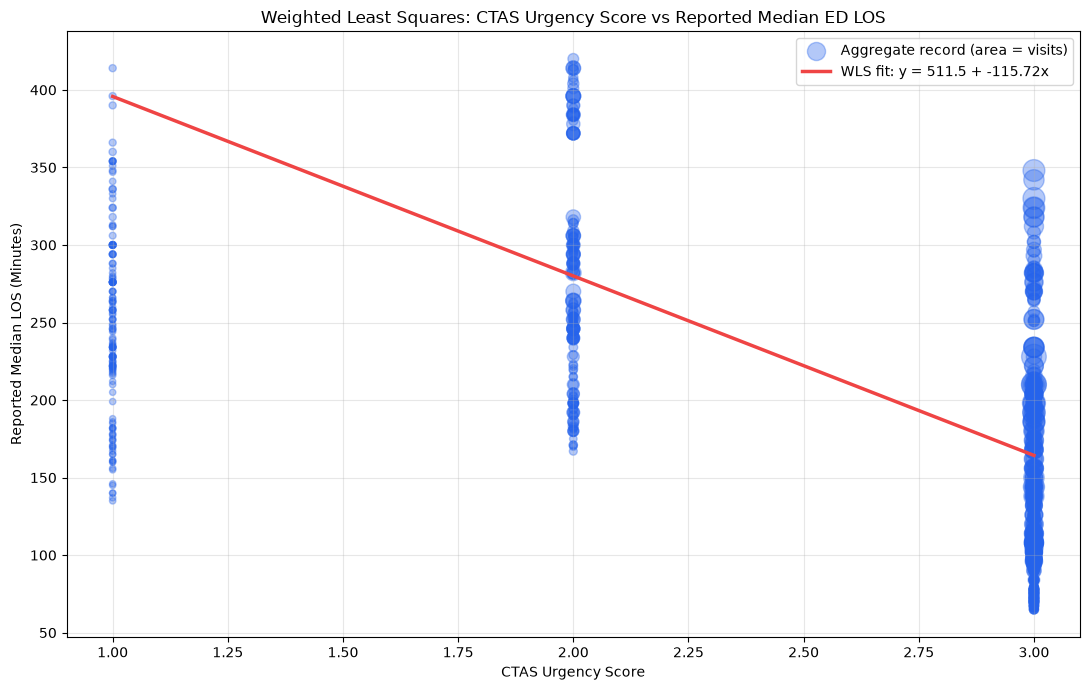

In [13]:
fig, ax = plt.subplots(figsize=(11, 7))

sizes = 20 + 300 * (w / w.max())
ax.scatter(x, y, s=sizes, alpha=0.35, color="#2563EB", label="Aggregate record (area = visits)")

grid = np.linspace(x.min(), x.max(), 100)
ax.plot(grid, intercept + slope * grid, color="#EF4444", linewidth=2.5,
        label=f"WLS fit: y = {intercept:.1f} + {slope:.2f}x")

ax.set_xlabel("CTAS Urgency Score")
ax.set_ylabel("Reported Median LOS (Minutes)")
ax.set_title("Weighted Least Squares: CTAS Urgency Score vs Reported Median ED LOS")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

,ctas_urgency_score,weighted_mean_los,total_visits,records
0,1,281.653671,1286555.0,152.0
1,2,291.007616,26742361.0,152.0
2,3,163.307595,146178479.0,456.0


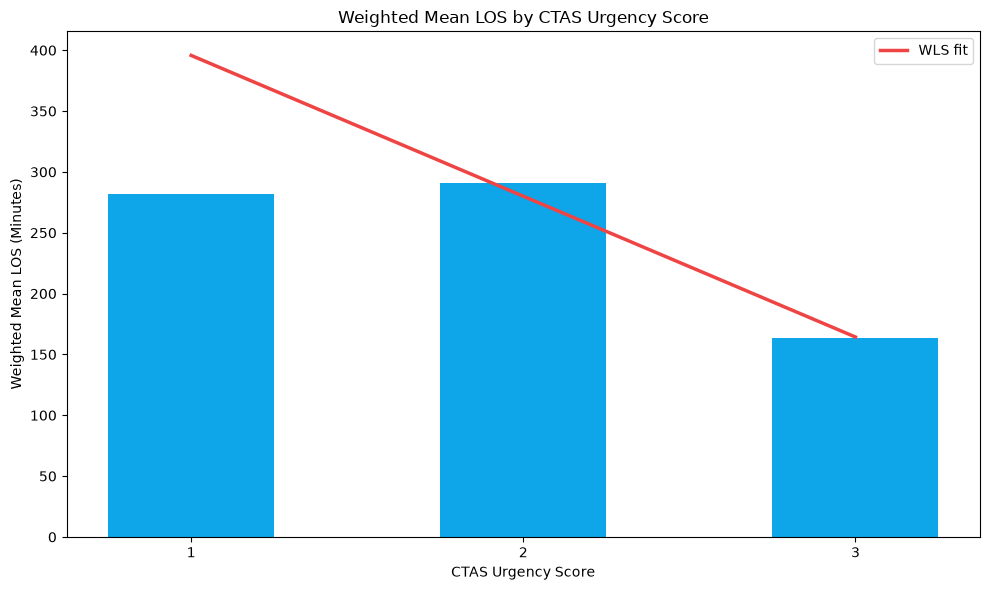

In [14]:
# Weighted mean LOS at each observed urgency score, with the fitted line over it.
by_score = (
    h3_df.groupby("ctas_urgency_score")
    .apply(lambda g: pd.Series({
        "weighted_mean_los": weighted_mean(g["median_los_minutes"].tolist(), g["ed_visits"].tolist()),
        "total_visits": g["ed_visits"].sum(),
        "records": len(g),
    }), include_groups=False)
    .reset_index()
)

display(by_score)

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(by_score["ctas_urgency_score"], by_score["weighted_mean_los"], color="#0EA5E9", width=0.5)
ax.plot(grid, intercept + slope * grid, color="#EF4444", linewidth=2.5, label="WLS fit")

ax.set_xlabel("CTAS Urgency Score")
ax.set_ylabel("Weighted Mean LOS (Minutes)")
ax.set_title("Weighted Mean LOS by CTAS Urgency Score")
ax.set_xticks(sorted(h3_df["ctas_urgency_score"].unique()))
ax.legend()

plt.tight_layout()
plt.show()

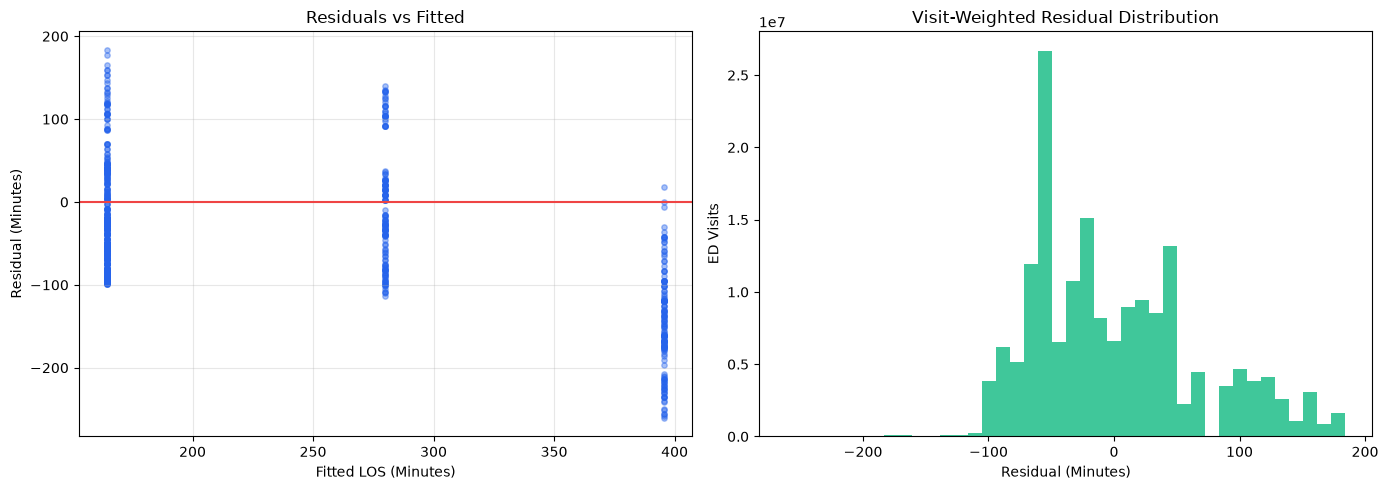

In [15]:
residuals = y - y_hat

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_hat, residuals, s=15, alpha=0.4, color="#2563EB")
axes[0].axhline(0, color="#EF4444", linewidth=1.5)
axes[0].set_xlabel("Fitted LOS (Minutes)")
axes[0].set_ylabel("Residual (Minutes)")
axes[0].set_title("Residuals vs Fitted")
axes[0].grid(alpha=0.3)

axes[1].hist(residuals, bins=40, weights=w, color="#10B981", alpha=0.8)
axes[1].set_xlabel("Residual (Minutes)")
axes[1].set_ylabel("ED Visits")
axes[1].set_title("Visit-Weighted Residual Distribution")

plt.tight_layout()
plt.show()

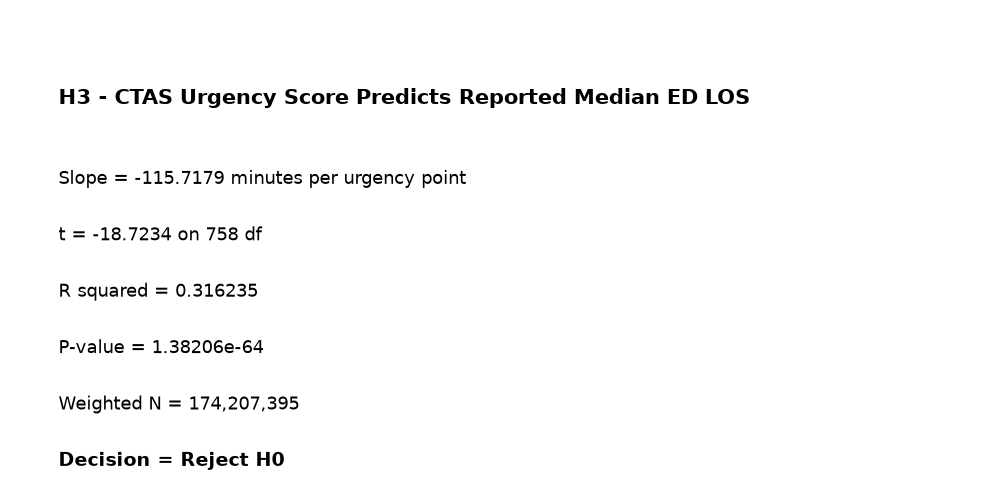

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.axis("off")

decision = "Reject H0" if p_value < ALPHA else "Fail to Reject H0"

ax.text(0.05, 0.80, "H3 - CTAS Urgency Score Predicts Reported Median ED LOS",
        fontsize=15, fontweight="bold")
ax.text(0.05, 0.63, f"Slope = {slope:.4f} minutes per urgency point", fontsize=13)
ax.text(0.05, 0.51, f"t = {t_stat:.4f} on {df_resid} df", fontsize=13)
ax.text(0.05, 0.39, f"R squared = {r_squared:.6f}", fontsize=13)
ax.text(0.05, 0.27, f"P-value = {p_value:.6g}", fontsize=13)
ax.text(0.05, 0.15, f"Weighted N = {int(W):,}", fontsize=13)
ax.text(0.05, 0.03, f"Decision = {decision}", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

In [17]:
# Parity check against the production endpoint, which fits via statsmodels.WLS.
from backend.analytics.regression import run_h3_regression

api = run_h3_regression()

print("NOTEBOOK vs PRODUCTION ENGINE")
print("=" * 80)
print(f"{'metric':22} {'notebook':>22} {'backend':>22}")
print(f"{'slope':22} {slope:>22.4f} {api['slope']:>22.4f}")
print(f"{'r_squared':22} {r_squared:>22.4f} {api['r_squared']:>22.4f}")
print(f"{'decision':22} {decision:>22} {api['decision']:>22}")
print()
print("Note: the backend reads the analytical database (built from the cleaned master")
print("workbook) while this notebook reads the Explorer CSV, so exact figures can")
print("differ slightly in row coverage. The METHOD (WLS via statsmodels) is identical.")

NOTEBOOK vs PRODUCTION ENGINE
metric                               notebook                backend
slope                               -115.7179              -116.5954
r_squared                              0.3162                 0.3163
decision                            Reject H0              Reject H₀

Note: the backend reads the analytical database (built from the cleaned master
workbook) while this notebook reads the Explorer CSV, so exact figures can
differ slightly in row coverage. The METHOD (WLS via statsmodels) is identical.
